#Przewidywanie globalnej sprzedaży gier wideo
**Cel projektu:** Zbudowanie modelu sztucznej inteligencji, który potrafi przewidzieć całkowitą globalną sprzedaż (w milionach kopii) danej gry wideo na podstawie jej parametrów, takich jak: rok wydania, platforma, gatunek i wydawca.

Projekt realizuje pełen cykl analizy danych (Data Science): od automatycznego pobrania danych z Kaggle, przez ich oczyszczenie i wizualizację, aż po trenowanie i optymalizację algorytmów uczenia maszynowego (Regresja Liniowa i Las Losowy).

In [1]:
# Instalujemy bibliotekę kagglehub (Colab może jej domyślnie nie mieć)
!pip install kagglehub -q

import kagglehub
import pandas as pd
import os

# 1. Pobranie danych bezpośrednio z Kaggle
print("Pobieranie danych...")
path = kagglehub.dataset_download("gregorut/videogamesales")
print(f"Dane zostały pobrane do folderu: {path}")

# 2. Utworzenie pełnej ścieżki do pliku CSV i wczytanie go do DataFrame
csv_file = os.path.join(path, "vgsales.csv")
df = pd.read_csv(csv_file)

# 3. Wyświetlenie 5 pierwszych wierszy
print("\n--- Pierwsze 5 wierszy zbioru ---")
display(df.head())

# 4. Sprawdzenie podstawowych informacji (typy danych, liczba niepustych wartości)
print("\n--- Informacje o zbiorze ---")
df.info()

Pobieranie danych...
Using Colab cache for faster access to the 'videogamesales' dataset.
Dane zostały pobrane do folderu: /kaggle/input/videogamesales

--- Pierwsze 5 wierszy zbioru ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



--- Informacje o zbiorze ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


## 1. Czyszczenie danych i Analiza Eksploracyjna (EDA)
Modele matematyczne nie potrafią uczyć się na pustych polach, dlatego pierwszym krokiem było usunięcie brakujących danych (`NaN`). Ponieważ stanowiły one zaledwie około 1.5% całego zbioru, bezpiecznie usunęliśmy te wiersze, zachowując jakość bazy.

**Wnioski z wykresów:**
1. Najlepiej sprzedającymi się gatunkami gier na świecie są zdecydowanie gry akcji (*Action*) oraz sportowe (*Sports*).
2. Analiza historyczna pokazuje, że rynek gier przeżywał ogromny "boom" wydawniczy w okolicach lat 2008-2010. (dane zostały wyciągniete pod koniec 2016 roku). Dystrybucja fizyczna oraz gry, które sprzedały powyżej 100 000 kopii.


--- 1. CZYSZCZENIE DANYCH ---
Rozmiar tabeli przed czyszczeniem: (16598, 11)
Rozmiar tabeli po czyszczeniu: (16291, 11)
Brakujące wartości usunięte. Rok zamieniony na liczbę całkowitą.

--- 2. WIZUALIZACJA DANYCH ---


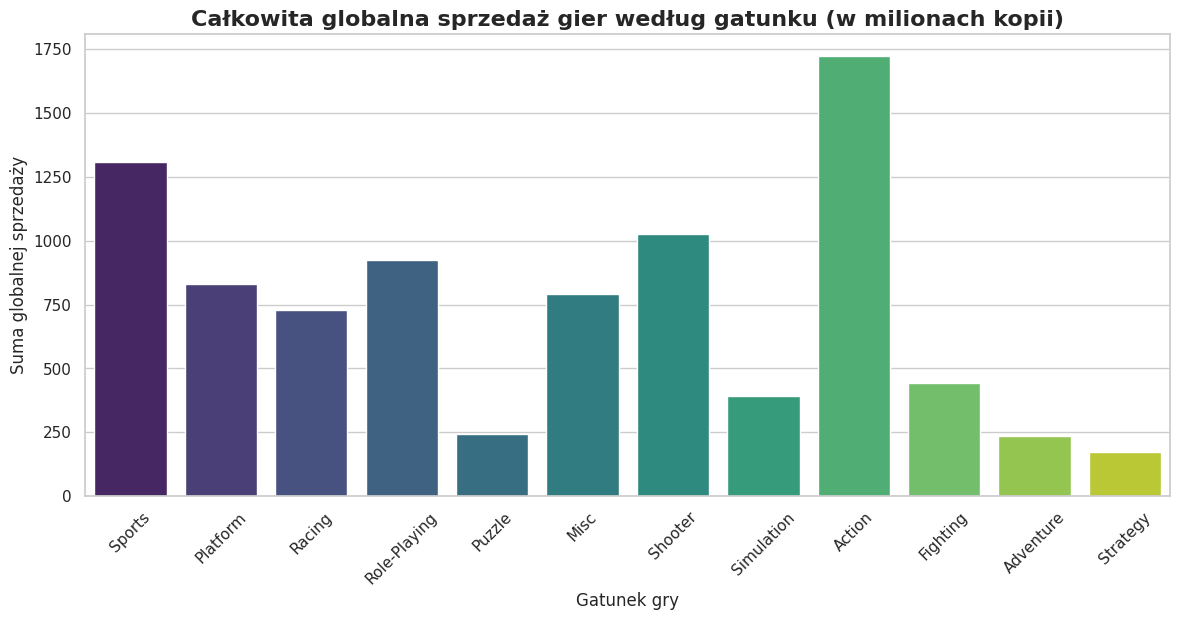

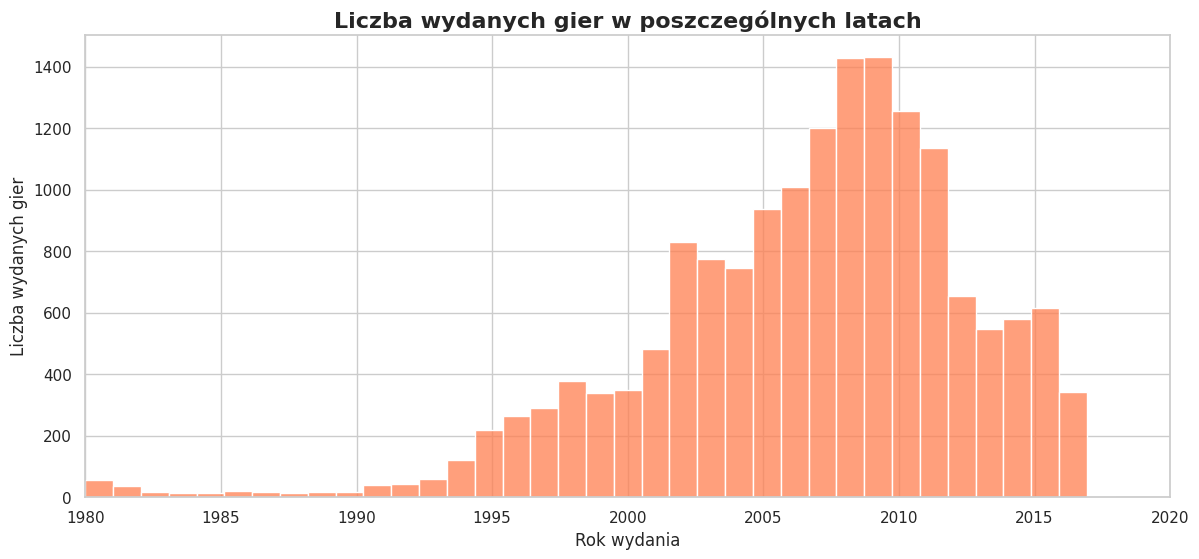

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. CZYSZCZENIE DANYCH ---")
print(f"Rozmiar tabeli przed czyszczeniem: {df.shape}")

# Ponieważ brakujących danych jest bardzo mało (około 1.5% całego zbioru),
# najbezpieczniejszą i najprostszą metodą będzie po prostu usunięcie tych wierszy.
df_clean = df.dropna().copy()

# Rok wydania jest zapisany jako liczba z ułamkiem (np. 2006.0).
# Zamieniamy to na ładne liczby całkowite (np. 2006).
df_clean['Year'] = df_clean['Year'].astype(int)

print(f"Rozmiar tabeli po czyszczeniu: {df_clean.shape}")
print("Brakujące wartości usunięte. Rok zamieniony na liczbę całkowitą.\n")

print("--- 2. WIZUALIZACJA DANYCH ---")
# Ustawiamy styl wykresów dla lepszej czytelności
sns.set_theme(style="whitegrid")

# Wykres 1: Globalna sprzedaż z podziałem na gatunki gier
plt.figure(figsize=(14, 6))
# Tworzymy wykres słupkowy. 'estimator=sum' sprawia, że sumujemy sprzedaż wszystkich gier z danego gatunku
sns.barplot(x='Genre', y='Global_Sales', data=df_clean, estimator=sum, errorbar=None, palette='viridis', hue='Genre', legend=False)
plt.title('Całkowita globalna sprzedaż gier według gatunku (w milionach kopii)', fontsize=16, fontweight='bold')
plt.xlabel('Gatunek gry', fontsize=12)
plt.ylabel('Suma globalnej sprzedaży', fontsize=12)
plt.xticks(rotation=45) # Obracamy podpisy na osi X, żeby na siebie nie nachodziły
plt.show()

# Wykres 2: Liczba wydanych gier na przestrzeni lat
plt.figure(figsize=(14, 6))
# Tworzymy histogram pokazujący rozkład wydawanych gier w czasie
sns.histplot(data=df_clean, x='Year', bins=len(df_clean['Year'].unique()), color='coral')
plt.title('Liczba wydanych gier w poszczególnych latach', fontsize=16, fontweight='bold')
plt.xlabel('Rok wydania', fontsize=12)
plt.ylabel('Liczba wydanych gier', fontsize=12)
plt.xlim(1980, 2020) # Ograniczamy oś X do 2020 roku, bo baza kończy się w tamtych okolicach
plt.show()

## 2. Przygotowanie danych pod ML (Inżynieria Cech)
Zanim dane trafiły do modeli, musieliśmy rozwiązać dwa kluczowe problemy:

1. **Uniknięcie Wycieku Danych (Data Leakage):** Z naszych danych wejściowych celowo **usunęliśmy** kolumny ze sprzedażą w Ameryce, Europie i Japonii. Dlaczego? Ponieważ naszą zmienną docelową jest `Global_Sales` (suma tych rynków). Gdybyśmy ich nie usunęli, model nie "uczyłby się" przewidywać na podstawie gatunku czy wydawcy, tylko używałby prostego dodawania. To zafałszowałoby jego skuteczność.
2. **Zamiana tekstu na liczby (One-Hot Encoding):** Modele ML rozumieją tylko matematykę. Użyliśmy funkcji `pd.get_dummies()`, aby zamienić nazwy kategoryczne (np. platformy "PS4", "PC") na osobne kolumny z wartościami 0 i 1.

Na koniec podzieliliśmy dane na **zbiór treningowy (80%)** – na którym algorytm się uczy, oraz **zbiór testowy (20%)** – który służy do obiektywnego sprawdzania (egzaminowania) skuteczności modelu.

--- 1. ANALIZA KORELACJI ---


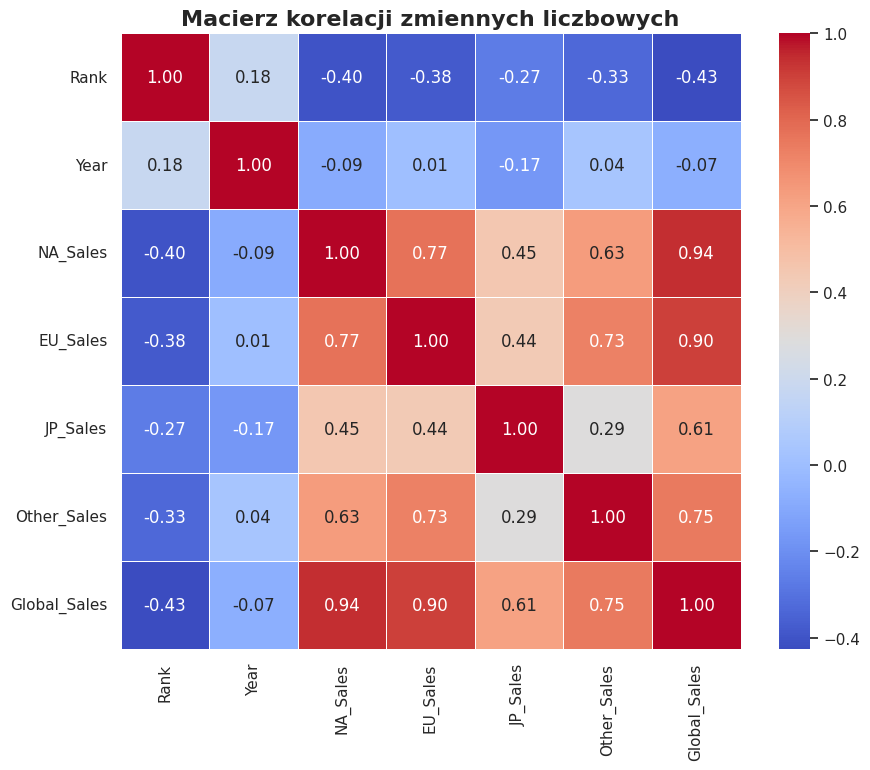


--- 2. PRZYGOTOWANIE DANYCH (ZAMIANA TEKSTU NA LICZBY) ---
Kształt danych przed kodowaniem: (16291, 4)
Kształt danych po kodowaniu: (16291, 617)

--- 3. PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY ---
Zbiór treningowy: 13032 wierszy
Zbiór testowy: 3259 wierszy
Dane są w 100% gotowe do trenowania modeli!


In [3]:
from sklearn.model_selection import train_test_split

print("--- 1. ANALIZA KORELACJI ---")
# Wybieramy tylko kolumny liczbowe do macierzy korelacji
numeric_cols = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
# Rysujemy mapę cieplną (heatmap), która pokaże zależności między zmiennymi
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji zmiennych liczbowych', fontsize=16, fontweight='bold')
plt.show()

print("\n--- 2. PRZYGOTOWANIE DANYCH (ZAMIANA TEKSTU NA LICZBY) ---")
# Oddzielamy to, co chcemy przewidzieć (y) od tego, na podstawie czego przewidujemy (X)
# Usuwamy kolumny powodujące wyciek danych oraz te nieprzydatne (Name, Rank)
X = df_clean.drop(['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Rank', 'Name'], axis=1)
y = df_clean['Global_Sales']

print(f"Kształt danych przed kodowaniem: {X.shape}")

# Zamieniamy zmienne tekstowe (kategoryczne) na liczbowe (0 i 1)
X_encoded = pd.get_dummies(X, columns=['Platform', 'Genre', 'Publisher'], drop_first=True)
print(f"Kształt danych po kodowaniu: {X_encoded.shape}")

print("\n--- 3. PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY ---")
# Dzielimy dane: 80% do nauki modelu (trening), 20% do sprawdzania jego wiedzy (test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Zbiór treningowy: {X_train.shape[0]} wierszy")
print(f"Zbiór testowy: {X_test.shape[0]} wierszy")
print("Dane są w 100% gotowe do trenowania modeli!")

## 3. Trenowanie i ewaluacja modeli (Regresja)
Zgodnie z wymogami projektu, zaimplementowano i porównano dwa różne modele regresyjne:
* **Linear Regression (Regresja Liniowa)** – klasyczny, prosty model szukający liniowych zależności.
* **Random Forest Regressor (Las Losowy)** – zaawansowany model oparty na budowie wielu drzew decyzyjnych, które wspólnie głosują nad ostatecznym wynikiem.

**Metryka oceny:** Do oceny jakości użyliśmy błędu **RMSE** (Root Mean Squared Error). Mówi nam on wprost, o ile milionów kopii gier nasz model myli się średnio w swoich przewidywaniach. Im wynik bliższy zeru, tym model jest lepszy.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

print("--- 1. MODEL 1: REGRESJA LINIOWA ---")
# Trenujemy model na danych treningowych
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Przewidujemy sprzedaż na danych testowych i liczymy błąd RMSE
lr_predictions = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print(f"Błąd RMSE (Regresja Liniowa): {lr_rmse:.2f} mln kopii")

print("\n--- 2. MODEL 2: LAS LOSOWY (RANDOM FOREST) ---")
# Trenujemy potężniejszy model (Las Losowy ze 100 drzewami decyzyjnymi)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Przewidujemy sprzedaż na danych testowych i liczymy błąd RMSE
rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Błąd RMSE (Las Losowy): {rf_rmse:.2f} mln kopii")

print("\n--- 3. PODSUMOWANIE ---")
if lr_rmse < rf_rmse:
    print(f"Lepszy model to Regresja Liniowa (myli się średnio o {lr_rmse:.2f} mln kopii).")
else:
    print(f"Lepszy model to Las Losowy (myli się średnio o {rf_rmse:.2f} mln kopii).")

--- 1. MODEL 1: REGRESJA LINIOWA ---
Błąd RMSE (Regresja Liniowa): 1.98 mln kopii

--- 2. MODEL 2: LAS LOSOWY (RANDOM FOREST) ---
Błąd RMSE (Las Losowy): 2.03 mln kopii

--- 3. PODSUMOWANIE ---
Lepszy model to Regresja Liniowa (myli się średnio o 1.98 mln kopii).


## 4. Tuning Hiperparametrów
Lepszym modelem okazała się regresja liniowa, lecz stwierdziłem że zoptymalizuje random forest z nadzieją, że stworzy lepszą predykcje. Zamiast ręcznie zgadywać, jakie ustawienia (np. ile drzew decyzyjnych użyć lub jak głębokie mają być), użyliśmy narzędzia **`RandomizedSearchCV`**.

Zautomatyzowało to proces testowania różnych kombinacji parametrów (przy użyciu walidacji krzyżowej), pozwalając algorytmowi samemu wybrać konfigurację, która minimalizuje błąd RMSE i chroni model przed tzw. przeuczeniem (overfittingiem). Ostatecznie pozwoliło to na uzyskanie najdokładniejszego możliwego przewidywania!


In [5]:
from sklearn.model_selection import RandomizedSearchCV

print("--- 4. OPTYMALIZACJA NAJLEPSZEGO MODELU (TUNING) ---")
# Definiujemy "siatkę" ustawień, które algorytm ma przetestować
param_grid = {
    'n_estimators': [50, 100, 200],      # Liczba drzew w lesie
    'max_depth': [None, 10, 20, 30],     # Maksymalna głębokość drzewa
    'min_samples_split': [2, 5, 10]      # Minimalna liczba próbek do podziału
}

# Inicjalizujemy "pusty" model Lasu Losowego
rf_for_tuning = RandomForestRegressor(random_state=42)

# Konfigurujemy narzędzie RandomizedSearchCV
# n_iter=5 oznacza, że wylosuje 5 różnych kombinacji z naszej siatki,
# cv=3 to walidacja krzyżowa (sprawdza każdy model 3 razy, żeby mieć pewność)
random_search = RandomizedSearchCV(
    rf_for_tuning,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("Szukam najlepszych parametrów... (daj mu chwilę, to skomplikowane obliczenia)")
# Trenujemy na różnych ustawieniach
random_search.fit(X_train, y_train)

# Wyciągamy wnioski i najlepszy możliwy model
print("\n--- WYNIKI OPTYMALIZACJI ---")
print(f"Najlepsze znalezione ustawienia to: {random_search.best_params_}")

best_rf_model = random_search.best_estimator_
best_predictions = best_rf_model.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

print(f"Zoptymalizowany błąd RMSE: {best_rmse:.2f} (milionów kopii)")

--- 4. OPTYMALIZACJA NAJLEPSZEGO MODELU (TUNING) ---
Szukam najlepszych parametrów... (daj mu chwilę, to skomplikowane obliczenia)

--- WYNIKI OPTYMALIZACJI ---
Najlepsze znalezione ustawienia to: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 20}
Zoptymalizowany błąd RMSE: 1.95 (milionów kopii)
